# 🧠 Brain Tumor Detection using VGG16 (Transfer Learning)

## Introduction

This notebook implements a brain tumor classification system using **transfer learning** with the **VGG16** convolutional neural network. MRI images are classified into multiple tumor categories to assist in automated diagnosis support.

The dataset is split into **train**, **validation**, and **test** sets. The validation set is used during training to monitor generalization performance (via early stopping) and to select the best model weights, while the test set is reserved for final, unbiased evaluation. The convolutional base of VGG16, pre-trained on ImageNet, is used for feature extraction, with custom dense layers added for classification.

## Evaluation Metrics

Model performance is assessed using the following metrics:

**Classification Report** — Precision, Recall, and F1-score per class:

$$
\text{Precision} = \frac{TP}{TP + FP}, \quad
\text{Recall} = \frac{TP}{TP + FN}, \quad
F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

**Confusion Matrix** — visualizes predicted vs. true labels across all classes.

**ROC Curve & AUC** — evaluates the model's ability to discriminate between classes:

$$
TPR = \frac{TP}{TP + FN}, \quad FPR = \frac{FP}{FP + TN}
$$

⚠️ **Disclaimer:** This model is for educational and research purposes only and is not intended for clinical or diagnostic use.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split


In [3]:
train_dir="/content/drive/MyDrive/archive/Training"
test_dir="/content/drive/MyDrive/archive/Testing"

# fill training lists with the path of images
train_img_paths=[]
train_labels=[]

for label in os.listdir(train_dir):
  for img_path in os.listdir(os.path.join(train_dir,label)):
    train_img_paths.append(os.path.join(train_dir,label,img_path))
    train_labels.append(label)

#fill the test lists with the path of images
test_img_paths=[]
test_labels=[]

for label in os.listdir(test_dir):
  for img_path in os.listdir(os.path.join(test_dir,label)):
    test_img_paths.append(os.path.join(test_dir,label,img_path))
    test_labels.append(label)

#divide the training set into an 85% training set and a 15% validation set
train_img_paths, val_img_paths, train_labels, val_labels = train_test_split(
    train_img_paths,
    train_labels,
    test_size=0.15,
    random_state=42,
    stratify=train_labels  # garde la même proportion de chaque classe dans train et val
)

#shuffle train and test lists
train_img_paths, train_labels= shuffle(train_img_paths, train_labels,random_state=42)
test_img_paths, test_labels=shuffle(test_img_paths, test_labels,random_state=42)


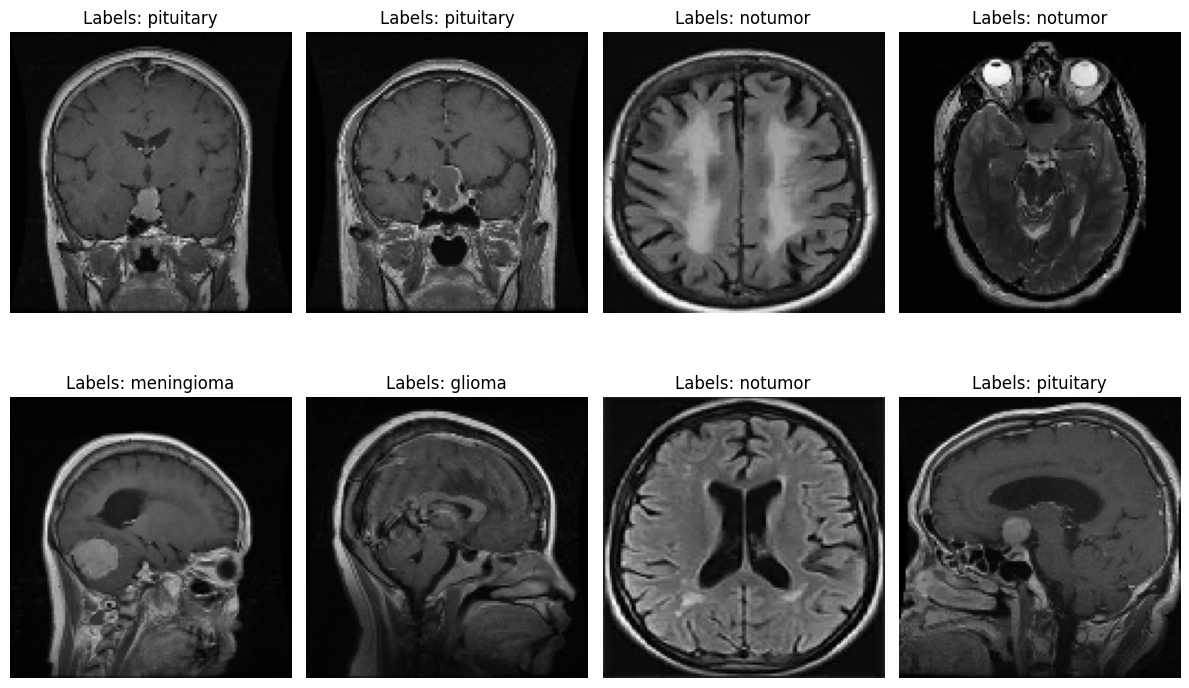

In [4]:
#Plot some examples of train Image
fig, axes=plt.subplots(2,4, figsize=(12,8))
axes=axes.ravel()

#set the image size
IMAGE_SIZE=128

for i,ax in enumerate(axes):
  img=load_img(train_img_paths[i],target_size=(IMAGE_SIZE,IMAGE_SIZE))
  ax.imshow(img)
  ax.axis("off")
  ax.set_title(f"Labels: {train_labels[i]}")

plt.tight_layout()
plt.show()


In [5]:
#data augmentation
def data_augment(image):
  if random.random()<0.5:
    image=ImageEnhance.Brightness(image).enhance(random.uniform(0.7,1.5))
  if random.random()<0.5:
    image=ImageEnhance.Contrast(image).enhance(random.uniform(0.7,1.8))
  if random.random()<0.5:
    angle = random.uniform(-10, 10)
    image = image.rotate(angle)
  image=img_to_array(image)/255.0
  return image

#open image and apply augmentation
def open_image(paths):
  images=[]
  for path in paths:
    image=load_img(path,target_size=(IMAGE_SIZE,IMAGE_SIZE))
    image=data_augment(image)
    images.append(image)

  return np.array(images)

#label encoding
unique_labels=sorted(os.listdir(train_dir))

def label_encode(labels):
  label_codes=[unique_labels.index(label) for label in labels]
  return np.array(label_codes)

#data generation
def gendata(paths,labels,batch_size=12):
  while True:
    paths,labels=shuffle(paths,labels)
    for i in range(0,len(paths),batch_size):
      batch_path=paths[i:i+batch_size]
      batch_images=open_image(batch_path)
      batch_labels=labels[i:i+batch_size]
      encode_batch_labels=label_encode(batch_labels)
      yield batch_images, encode_batch_labels

#generate validation images
def open_image_val(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = img_to_array(image) / 255.0
        images.append(image)
    return np.array(images)

def gendata_val(paths, labels, batch_size=12):
    while True:
        for i in range(0, len(paths), batch_size):
            batch_path = paths[i:i+batch_size]
            batch_images = open_image_val(batch_path)
            batch_labels = labels[i:i+batch_size]
            encode_batch_labels = label_encode(batch_labels)
            yield batch_images, encode_batch_labels


In [6]:
#Base Model
base_model=VGG16(input_shape=(IMAGE_SIZE,IMAGE_SIZE,3),include_top=False, weights="imagenet")

#freeze layers to avoid change learned_weights
for layer in base_model.layers:
  layer.trainable=False

#unfreeze last 6 layers
for layer in base_model.layers[-6:]:
  layer.trainable=True

#build the model
model=Sequential()
model.add(Input(shape=(IMAGE_SIZE,IMAGE_SIZE,3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))
model.add(Dense(128,activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(len(os.listdir(train_dir)),activation="softmax"))
model.compile(optimizer=Adam(learning_rate=0.0001),loss="sparse_categorical_crossentropy",metrics=["sparse_categorical_accuracy"])

#Parameters
batch_size=32
epochs=10
steps=len(train_img_paths)//batch_size #steps_per_epoch
val_steps = len(val_img_paths) // batch_size

#Define the early stop
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

#train the model
history=model.fit(gendata(train_img_paths,train_labels,batch_size=batch_size),
                  validation_data=gendata_val(val_img_paths, val_labels, batch_size=batch_size),
                  validation_steps=val_steps,
                  epochs=epochs,
                  steps_per_epoch=steps,
                  callbacks=[early_stop]
                  )

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2793s 19s/step - loss: 0.5269 - sparse_categorical_accuracy: 0.7929 - val_loss: 0.3198 - val_sparse_categorical_accuracy: 0.8930
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1517s 10s/step - loss: 0.2554 - sparse_categorical_accuracy: 0.9038 - val_loss: 0.1581 - val_sparse_categorical_accuracy: 0.9543
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1516s 10s/step - loss: 0.1556 - sparse_categorical_accuracy: 0.9385 - val_loss: 0.1885 - val_sparse_categorical_accuracy: 0.9307
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1523s 10s/step - loss: 0.1319 - sparse_categorical_accuracy: 0.9528 - val_loss: 0.1331 - val_sparse_categorical_accuracy: 0.9592
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1505s 10s/step - loss: 0.0947 - sparse_categorical_accuracy: 0.9681 - val_loss: 0.2115 - val_sparse_categorical_accuracy: 0.9418
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1503s 10s/step - loss: 0.0794 - sparse_categorical_accuracy: 0.9

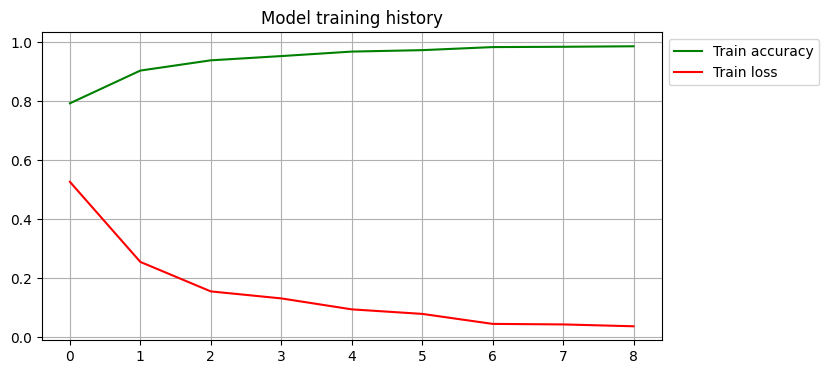

In [7]:
#plot the value of each tracked metric after every epoch of training
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history["sparse_categorical_accuracy"],label="Train accuracy",color='g')
plt.plot(history.history["loss"],label="Train loss",color='r')
plt.title("Model training history")
plt.legend(loc="upper left",bbox_to_anchor=(1,1))
plt.show()

In [8]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

images=open_image(test_img_paths)
encode_test_labels=label_encode(test_labels)
predictions=model.predict(images)

#classification report
print("Classification report: ")
print(classification_report(encode_test_labels,np.argmax(predictions,axis=1)))


50/50 ━━━━━━━━━━━━━━━━━━━━ 324s 6s/step
Classification report: 
              precision    recall  f1-score   support

           0       0.93      0.82      0.87       400
           1       0.90      0.91      0.91       400
           2       0.92      0.99      0.96       400
           3       0.96      0.98      0.97       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600



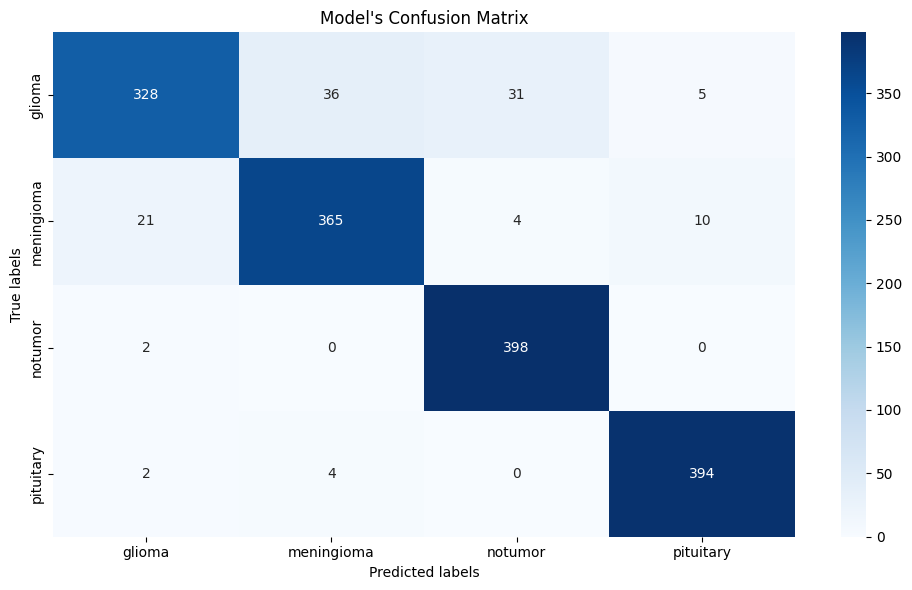

In [9]:
#Confusion matrix
cm=confusion_matrix(encode_test_labels,np.argmax(predictions,axis=1))
train_labels_sorted=sorted(os.listdir(train_dir))
test_labels_sorted=sorted(os.listdir(test_dir))

plt.figure(figsize=(10,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=train_labels_sorted,yticklabels=test_labels_sorted)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Model's Confusion Matrix")
plt.tight_layout()
plt.show()


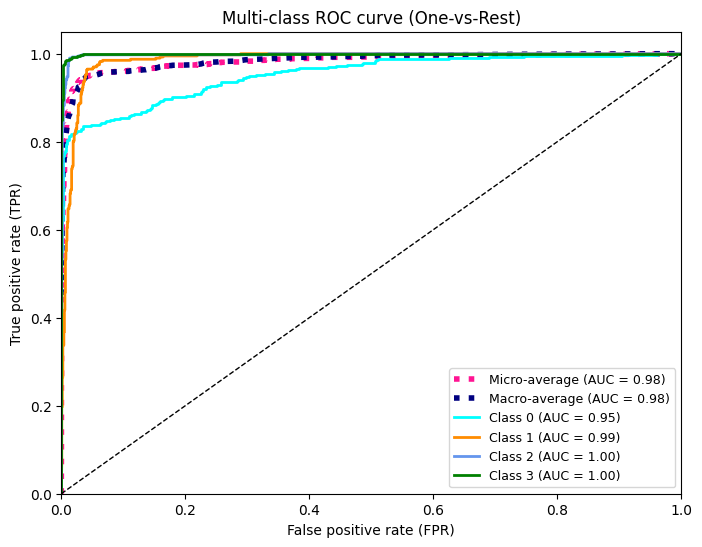

In [10]:
classes = sorted(label_encode(os.listdir(test_dir)))
n_classes = len(classes)

# convert multi-class labels into a one-vs-all (one-hot encoded) binary matrix.
y_test_bin = label_binarize(encode_test_labels, classes=classes)

# Calculate ROC and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- Micro-average (aggregates all points) ---
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), predictions.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# --- Macro-average (simple average of FPR/TPR) ---
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# --- Trace ---
plt.figure(figsize=(8, 6))

plt.plot(fpr["micro"], tpr["micro"],label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})',color='deeppink', linestyle=':', linewidth=4)

plt.plot(fpr["macro"], tpr["macro"],label=f'Macro-average (AUC = {roc_auc["macro"]:.2f})',color='navy', linestyle=':', linewidth=4)

colors =['aqua', 'darkorange', 'cornflowerblue', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False positive rate (FPR)')
plt.ylabel('True positive rate (TPR)')
plt.title('Multi-class ROC curve (One-vs-Rest)')
plt.legend(loc='lower right', fontsize=9)
plt.show()

In [17]:
#save the entire model
model.save("model.h5")

In [18]:
from tensorflow.keras.models import load_model

#load the trained model
model=load_model("model.h5")

In [16]:
def detect_tumor(image_path,model):
  #load image and convert it to numpy array
  image=load_img(image_path,target_size=(IMAGE_SIZE,IMAGE_SIZE))
  img_array=img_to_array(image)/255.0
  img_array=np.expand_dims(img_array,axis=0)

  #Make prediction using the Model
  prediction=model.predict(img_array)
  predicted_indice_class=np.argmax(prediction)
  predict_label=sorted(os.listdir(train_dir))[predicted_indice_class]
  confidance_score=np.max(prediction,axis=1)[0]*100

  #Plot the image
  plt.figure(figsize=(4,4))
  plt.imshow(image)
  if predict_label=="notumar":
    plt.title(f"No tumor,(confidence={confidance_score:.2f}%)")
  else:
    plt.title(f"Tumor: {predict_label},(confidence={confidance_score:.2f}%)")
  plt.axis("off")
  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


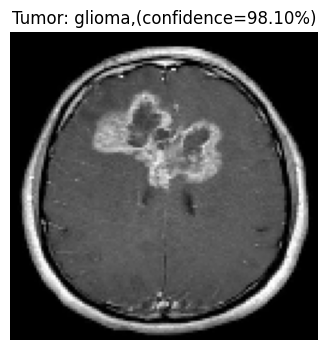

In [15]:
img_path="/content/glioma.jfif"
reel_label="glioma"

detect_tumor(img_path,model)